# Return Attribution Models #

In [1]:
# Import Libraries

# Data Management
import pandas as pd
import numpy as np

# Plots
import matplotlib.pyplot as plt

# Handle Files
import sys
import os

# Import Local Functions
sys.path.append(os.path.abspath("../source"))
from config import get_tickers
from data_downloader import get_market_data
from markowitz_portfolios_toolkit import markowitz_weights

### Building a Portfolio ###

In [2]:
stocks_tickers = get_tickers("6.1a")

stocks_tickers

['AAPL', 'JNJ', 'JPM', 'AMZN', 'XOM', 'UNP', 'PLD']

In [3]:
sectors_tickers = get_tickers("6.1b")

sectors_tickers

['XLK', 'XLV', 'XLF', 'XLY', 'XLE', 'XLI', 'XLRE']

In [4]:
# DataFrame to store everything
stock_returns_df = pd.DataFrame()

for ticker in stocks_tickers:
    df_stock = get_market_data(
        ticker=ticker, 
        start_date='2020-01-01', 
        end_date='2026-01-01', 
        returns=True
    )
    
    returns = df_stock['returns'].rename(ticker)
    
    stock_returns_df = pd.concat([stock_returns_df, returns], axis=1)

In [5]:
stock_returns_df

,AAPL,JNJ,JPM,AMZN,XOM,UNP,PLD
2020-01-03 00:00:00,-0.009770,-0.011645,-0.013284,-0.012213,-0.008072,-0.007103,0.011137
2020-01-06 00:00:00,0.007936,-0.001248,-0.000796,0.014776,0.007649,-0.008601,-0.003923
2020-01-07 00:00:00,-0.004714,0.006088,-0.017147,0.002089,-0.008218,-0.007609,-0.006422
2020-01-08 00:00:00,0.015958,-0.000138,0.007771,-0.007839,-0.015195,0.010891,0.005411
2020-01-09 00:00:00,0.021018,0.002962,0.003644,0.004788,0.007627,-0.005124,0.000112
...,...,...,...,...,...,...,...
2025-09-24 00:00:00,-0.008367,0.000623,0.002172,-0.002268,0.005339,0.010385,-0.013903
2025-09-25 00:00:00,0.017912,0.005869,0.000096,-0.009399,0.008951,0.007094,0.003096
2025-09-26 00:00:00,-0.005504,0.011079,0.008292,0.007444,0.014003,0.013699,0.008619
2025-09-29 00:00:00,-0.004040,0.010572,-0.001171,0.010816,-0.025926,0.004158,0.000438


In [6]:
# Portfolio's Expected Returns
expected_returns = stock_returns_df.mean()
expected_returns.name = 'mean_returns'

expected_returns

AAPL    0.000867
JNJ     0.000275
JPM     0.000664
AMZN    0.000579
XOM     0.000506
UNP     0.000265
PLD     0.000283
Name: mean_returns, dtype: float64

In [7]:
# Covariance Matrix
covariance_matrix = stock_returns_df.cov()

covariance_matrix

,AAPL,JNJ,JPM,AMZN,XOM,UNP,PLD
AAPL,0.000412,0.000084,0.000174,0.000274,0.000128,0.000161,0.000214
JNJ,0.000084,0.000156,0.000092,0.000038,0.000075,0.000085,0.000109
JPM,0.000174,0.000092,0.000398,0.000137,0.000235,0.000216,0.000193
AMZN,0.000274,0.000038,0.000137,0.000509,0.000074,0.000115,0.000186
XOM,0.000128,0.000075,0.000235,0.000074,0.000442,0.000172,0.000133
UNP,0.000161,0.000085,0.000216,0.000115,0.000172,0.000293,0.000190
PLD,0.000214,0.000109,0.000193,0.000186,0.000133,0.000190,0.000394


In [8]:
# Correlation Matrix
correlation_matrix = stock_returns_df.corr()

correlation_matrix

,AAPL,JNJ,JPM,AMZN,XOM,UNP,PLD
AAPL,1.000000,0.331202,0.428779,0.597031,0.299124,0.463391,0.531571
JNJ,0.331202,1.000000,0.370885,0.134905,0.287604,0.398425,0.440843
JPM,0.428779,0.370885,1.000000,0.305128,0.561220,0.631095,0.488311
AMZN,0.597031,0.134905,0.305128,1.000000,0.154979,0.297211,0.414461
XOM,0.299124,0.287604,0.561220,0.154979,1.000000,0.477729,0.318904
UNP,0.463391,0.398425,0.631095,0.297211,0.477729,1.000000,0.558730
PLD,0.531571,0.440843,0.488311,0.414461,0.318904,0.558730,1.000000


In [9]:
# Obtain Weights
p_weights = markowitz_weights(
    expected_returns, 
    covariance_matrix,
    0.0010
)

In [10]:
# Create a Portfolio Weights DF
portfolio_weights = pd.Series(
    p_weights,
    index = stock_returns_df.columns,
    name = 'weights'
)

portfolio_weights

AAPL    0.799390
JNJ     0.320301
JPM     0.527868
AMZN    0.044027
XOM     0.136455
UNP    -0.453305
PLD    -0.374737
Name: weights, dtype: float64

In [11]:
# Portfolio Returns
portfolio_returns = stock_returns_df @ p_weights
portfolio_returns.name = 'portfolio_returns'

portfolio_returns

2020-01-03   -0.021145
2020-01-06    0.012588
2020-01-07   -0.006043
2020-01-08    0.007431
2020-01-09    0.023206
                ...   
2025-09-24   -0.004212
2025-09-25    0.012680
2025-09-26   -0.003675
2025-09-29   -0.005572
2025-09-30   -0.000938
Name: portfolio_returns, Length: 1443, dtype: float64

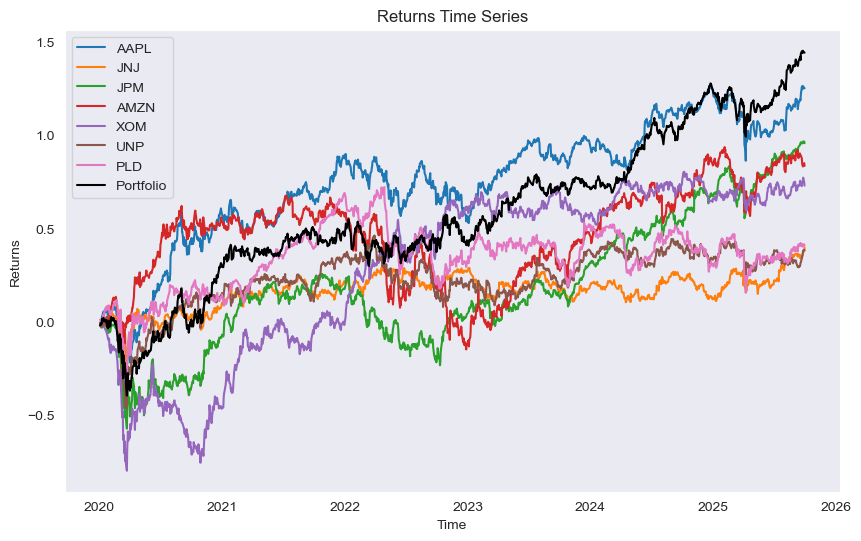

In [12]:
# Create Plot
plt.figure(figsize=(10, 6))
plt.plot(stock_returns_df.cumsum(), label=stock_returns_df.columns, alpha=1)
plt.plot(portfolio_returns.cumsum(), label='Portfolio', color='black', alpha=1)

# Config
plt.title('Returns Time Series')
plt.xlabel('Time')
plt.ylabel('Returns')
plt.legend()
plt.grid()

# Show
plt.show() 

### Getting a Benchmark: Using a Hypothetical Portfolio ###

In [13]:
# DataFrame to store everything
sector_returns_df = pd.DataFrame()

for ticker in sectors_tickers:
    df_stock = get_market_data(
        ticker=ticker, 
        start_date='2020-01-01', 
        end_date='2026-01-01', 
        returns=True
    )
    
    returns = df_stock['returns'].rename(ticker)
    
    sector_returns_df = pd.concat([sector_returns_df, returns], axis=1)

In [14]:
sector_returns_df

,XLK,XLV,XLF,XLY,XLE,XLI,XLRE
2020-01-03 00:00:00,-0.011307,-0.008752,-0.010675,-0.008546,-0.002976,-0.001929,0.007299
2020-01-06 00:00:00,0.002380,0.006204,-0.000651,0.002778,0.007752,0.000362,0.000260
2020-01-07 00:00:00,-0.000432,-0.001965,-0.006529,-0.001586,-0.002632,-0.002053,-0.010966
2020-01-08 00:00:00,0.010644,0.006471,0.006529,0.003012,-0.016609,0.003380,0.004976
2020-01-09 00:00:00,0.011272,0.004291,0.006164,0.005288,0.007342,0.004209,-0.000261
...,...,...,...,...,...,...,...
2025-09-24 00:00:00,-0.006193,-0.004024,-0.002794,0.007036,0.012923,-0.005175,-0.010291
2025-09-25 00:00:00,-0.001761,-0.016709,-0.002615,-0.014207,0.008926,-0.006788,-0.002408
2025-09-26 00:00:00,0.003017,0.010162,0.007267,0.014666,0.009173,0.008953,0.009838
2025-09-29 00:00:00,0.005329,0.002948,0.005000,0.004371,-0.018542,0.003076,0.001908


In [15]:
# Get the returns of each stock of our portfolio but in the IWY
bench_weights = pd.Series(
    [31.6, 9.6, 14.3, 10.6, 3.0, 8.7, 2.1],
    index = sector_returns_df.columns,
    name = 'weights'
)

bench_weights = bench_weights/100

bench_weights

XLK     0.316
XLV     0.096
XLF     0.143
XLY     0.106
XLE     0.030
XLI     0.087
XLRE    0.021
Name: weights, dtype: float64

In [16]:
# Normalized
norm_bench_weights = bench_weights/bench_weights.sum()

norm_bench_weights

XLK     0.395494
XLV     0.120150
XLF     0.178974
XLY     0.132666
XLE     0.037547
XLI     0.108886
XLRE    0.026283
Name: weights, dtype: float64

In [17]:
# Build the Benchmark Returns
benchmark_returns = sector_returns_df @ norm_bench_weights
benchmark_returns.name = 'benchmark_returns'

benchmark_returns

2020-01-03   -0.008698
2020-01-06    0.002276
2020-01-07   -0.002397
2020-01-08    0.006430
2020-01-09    0.007505
                ...   
2025-09-24   -0.002848
2025-09-25   -0.005524
2025-09-26    0.007238
2025-09-29    0.003626
2025-09-30   -0.002225
Name: benchmark_returns, Length: 1443, dtype: float64

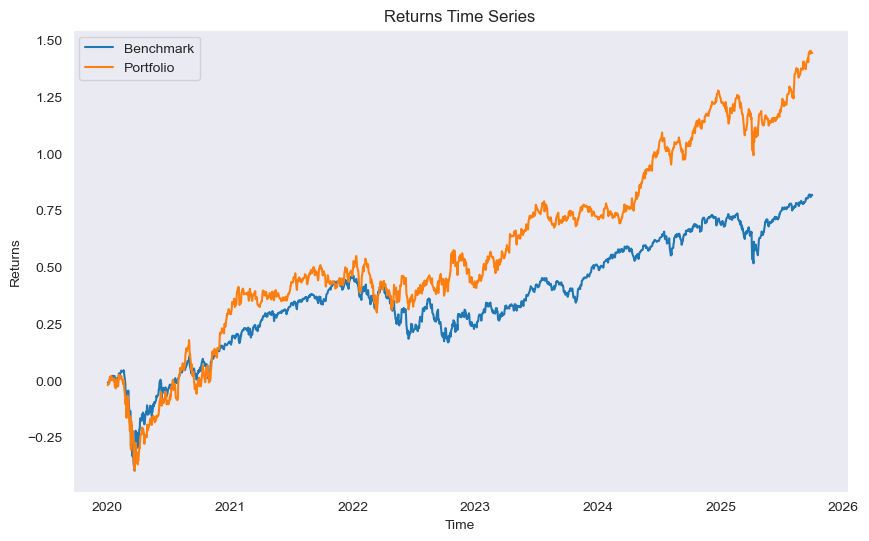

In [18]:
# Create Plot
plt.figure(figsize=(10, 6))
plt.plot(benchmark_returns.cumsum(), label='Benchmark', alpha=1)
plt.plot(portfolio_returns.cumsum(), label='Portfolio', alpha=1)

# Config
plt.title('Returns Time Series')
plt.xlabel('Time')
plt.ylabel('Returns')
plt.legend()
plt.grid()

# Show
plt.show() 

In [19]:
# Calculate the Mean Returns
portfolio_total_returns = portfolio_returns.cumsum().iloc[-1]
benchmark_total_returns = benchmark_returns.cumsum().iloc[-1]

print(portfolio_total_returns)
print(benchmark_total_returns)

1.4430000000000003
0.8164260725275332


In [21]:
# Calculate the Excess Returns
excess_returns = portfolio_total_returns - benchmark_total_returns

excess_returns

0.6265739274724671

In [22]:
# Sectors List
sectors_list = [
    "Technology",
    "Health",
    "Financials",
    "Consumer",
    "Energy",
    "Industrials",
    "Real_Estate"
]

In [23]:
stock_returns_df.columns = sectors_list
sector_returns_df.columns = sectors_list

In [24]:
portfolio_weights.index = sectors_list
norm_bench_weights.index = sectors_list

The calculations of the effects in the Brinson-Fachler Model can be reviewed in the first section of this module's PDF. The mathematical derivations and explanations are provided there.

In [25]:
# Create a Comparison DF
comparison_df = pd.DataFrame(index = sectors_list)
comparison_df['portfolio_weights'] = portfolio_weights
comparison_df['benchmark_weights'] = norm_bench_weights
comparison_df['stocks_returns'] = stock_returns_df.cumsum().iloc[-1]
comparison_df['sector_returns'] = sector_returns_df.cumsum().iloc[-1]
comparison_df['portfolio_returns'] = comparison_df['portfolio_weights'] * comparison_df['stocks_returns']
comparison_df['benchmark_returns'] = comparison_df['benchmark_weights'] * comparison_df['sector_returns']

# The Alphas (Portfolio - Benchmark)
comparison_df['alphas'] = comparison_df['stocks_returns'] - comparison_df['sector_returns']
comparison_df['weights_diff'] = comparison_df['portfolio_weights'] - comparison_df['benchmark_weights']

comparison_df

,portfolio_weights,benchmark_weights,stocks_returns,sector_returns,portfolio_returns,benchmark_returns,alphas,weights_diff
Technology,0.799390,0.395494,1.251435,1.148891,1.000385,0.454380,0.102544,0.403896
Health,0.320301,0.120150,0.397186,0.394697,0.127219,0.047423,0.002489,0.200151
Financials,0.527868,0.178974,0.957439,0.651040,0.505402,0.116519,0.306400,0.348894
Consumer,0.044027,0.132666,0.835740,0.679888,0.036795,0.090198,0.155852,-0.088639
Energy,0.136455,0.037547,0.729632,0.628057,0.099562,0.023582,0.101575,0.098908
Industrials,-0.453305,0.108886,0.382824,0.706287,-0.173536,0.076905,-0.323462,-0.562191
Real_Estate,-0.374737,0.026283,0.407825,0.282303,-0.152827,0.007420,0.125522,-0.401020


In [26]:
# Check the sum
comparison_df.sum()

portfolio_weights    1.000000e+00
benchmark_weights    1.000000e+00
stocks_returns       4.962082e+00
sector_returns       4.491163e+00
portfolio_returns    1.443000e+00
benchmark_returns    8.164261e-01
alphas               4.709197e-01
weights_diff        -1.110223e-16
dtype: float64

In [27]:
# Calculate the Brinson-Fachler Allocation Effect
allocation_effect = comparison_df['weights_diff'] * (comparison_df['sector_returns'] - comparison_df['benchmark_returns'].sum())
allocation_effect.name = 'allocation_effect'

allocation_effect

Technology     0.134281
Health        -0.084410
Financials    -0.057702
Consumer       0.012103
Energy        -0.018631
Industrials    0.061919
Real_Estate    0.214194
Name: allocation_effect, dtype: float64

In [28]:
# Calculate the Brinson-Fachler Selection Effect
selection_effect = comparison_df['benchmark_weights'] * comparison_df['alphas']
selection_effect.name = 'selection_effect'

selection_effect

Technology     0.040556
Health         0.000299
Financials     0.054838
Consumer       0.020676
Energy         0.003814
Industrials   -0.035221
Real_Estate    0.003299
Name: selection_effect, dtype: float64

In [29]:
# Calculate the Brinson-Fachler Intersection Effect
interaction_effect = comparison_df['weights_diff'] * comparison_df['alphas']
interaction_effect.name = 'interaction_effect'

interaction_effect

Technology     0.041417
Health         0.000498
Financials     0.106901
Consumer      -0.013815
Energy         0.010047
Industrials    0.181848
Real_Estate   -0.050337
Name: interaction_effect, dtype: float64

In [30]:
# Calculate the Total Effect
bf_total_attribution = (
        allocation_effect + 
        selection_effect +
        interaction_effect
)

bf_total_attribution.name = 'bf_total_attribution'

bf_total_attribution

Technology     0.216254
Health        -0.083612
Financials     0.104036
Consumer       0.018964
Energy        -0.004771
Industrials    0.208546
Real_Estate    0.167156
Name: bf_total_attribution, dtype: float64

In [31]:
# Show
brinson_fachler_df = pd.DataFrame({
    'allocation': allocation_effect,
    'selection': selection_effect,
    'interaction': interaction_effect,
    'total': bf_total_attribution
})

brinson_fachler_df

,allocation,selection,interaction,total
Technology,0.134281,0.040556,0.041417,0.216254
Health,-0.084410,0.000299,0.000498,-0.083612
Financials,-0.057702,0.054838,0.106901,0.104036
Consumer,0.012103,0.020676,-0.013815,0.018964
Energy,-0.018631,0.003814,0.010047,-0.004771
Industrials,0.061919,-0.035221,0.181848,0.208546
Real_Estate,0.214194,0.003299,-0.050337,0.167156


In [32]:
brinson_fachler_df.sum().round(6)

allocation     0.261754
selection      0.088261
interaction    0.276559
total          0.626574
dtype: float64

In [33]:
# Divide the DataFrame by the Excess Return
norm_brinson_fachler_df = (brinson_fachler_df/brinson_fachler_df['total'].sum()) * 100

norm_brinson_fachler_df

,allocation,selection,interaction,total
Technology,21.431058,6.472588,6.610088,34.513734
Health,-13.471610,0.047726,0.079505,-13.344379
Financials,-9.209194,8.751963,17.061221,16.603989
Consumer,1.931545,3.299887,-2.204777,3.026656
Energy,-2.973522,0.608682,1.603425,-0.761416
Industrials,9.882200,-5.621136,29.022547,33.283611
Real_Estate,34.184953,0.526527,-8.033676,26.677805


In [34]:
norm_brinson_fachler_df.sum().round(2)

allocation      41.78
selection       14.09
interaction     44.14
total          100.00
dtype: float64

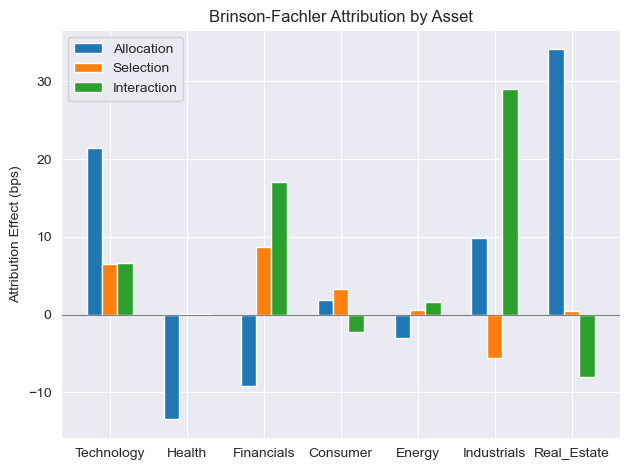

In [35]:
# Plotting individual attribution effects per asset
fig, ax = plt.subplots()

bar_width = 0.2
x = np.arange(len(norm_brinson_fachler_df))

# Plot each component
ax.bar(x - bar_width, norm_brinson_fachler_df["allocation"], width=bar_width, label="Allocation")
ax.bar(x, norm_brinson_fachler_df["selection"], width=bar_width, label="Selection")
ax.bar(x + bar_width, norm_brinson_fachler_df["interaction"], width=bar_width, label="Interaction")

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(norm_brinson_fachler_df.index)
ax.set_ylabel("Attribution Effect (bps)")
ax.set_title("Brinson-Fachler Attribution by Asset")
ax.legend()
ax.axhline(0, color="gray", linewidth=0.8)

plt.tight_layout()
plt.show()

### Brinson-Hood-Beebower Model ###

To understand the differences between the BHB Model and the Brinson-Fachler Model, the reader can refer to Section 2 of this module’s PDF. There, you will find a detailed explanation of why the BHB Model is also used.

In [36]:
# Let us define the portfolios

# Quadrant IV Portfolio
pure_active_portfolio = stock_returns_df @ portfolio_weights
pure_active_portfolio.name = 'pure_active_portfolio_returns'

pure_active_portfolio 

2020-01-03   -0.021145
2020-01-06    0.012588
2020-01-07   -0.006043
2020-01-08    0.007431
2020-01-09    0.023206
                ...   
2025-09-24   -0.004212
2025-09-25    0.012680
2025-09-26   -0.003675
2025-09-29   -0.005572
2025-09-30   -0.000938
Name: pure_active_portfolio_returns, Length: 1443, dtype: float64

In [37]:
# Quadrant I Portfolio
pure_pasive_portfolio = sector_returns_df @ norm_bench_weights
pure_pasive_portfolio.name = 'pure_pasive_portfolio_returns'

pure_pasive_portfolio

2020-01-03   -0.008698
2020-01-06    0.002276
2020-01-07   -0.002397
2020-01-08    0.006430
2020-01-09    0.007505
                ...   
2025-09-24   -0.002848
2025-09-25   -0.005524
2025-09-26    0.007238
2025-09-29    0.003626
2025-09-30   -0.002225
Name: pure_pasive_portfolio_returns, Length: 1443, dtype: float64

In [38]:
# Quadrant II Portfolio (Active Allocation Passive Selection)
aaps_portfolio = sector_returns_df @ portfolio_weights
aaps_portfolio.name = 'aaps_portfolio_returns'

aaps_portfolio

2020-01-03   -0.020120
2020-01-06    0.004465
2020-01-07    0.000189
2020-01-08    0.008497
2020-01-09    0.013063
                ...   
2025-09-24    0.000561
2025-09-25   -0.003568
2025-09-26    0.003655
2025-09-29    0.003397
2025-09-30   -0.003873
Name: aaps_portfolio_returns, Length: 1443, dtype: float64

In [49]:
# Quadrant III Portfolio (Passive Allocation Active Selection)
paas_portfolio = stock_returns_df @ norm_bench_weights
paas_portfolio.name = 'paas_portfolio_returns'

paas_portfolio

2020-01-03   -0.010045
2020-01-06    0.004054
2020-01-07   -0.005230
2020-01-08    0.007403
2020-01-09    0.009687
                ...   
2025-09-24   -0.002181
2025-09-25    0.007749
2025-09-26    0.003870
2025-09-29    0.000388
2025-09-30   -0.004141
Name: paas_portfolio_returns, Length: 1443, dtype: float64

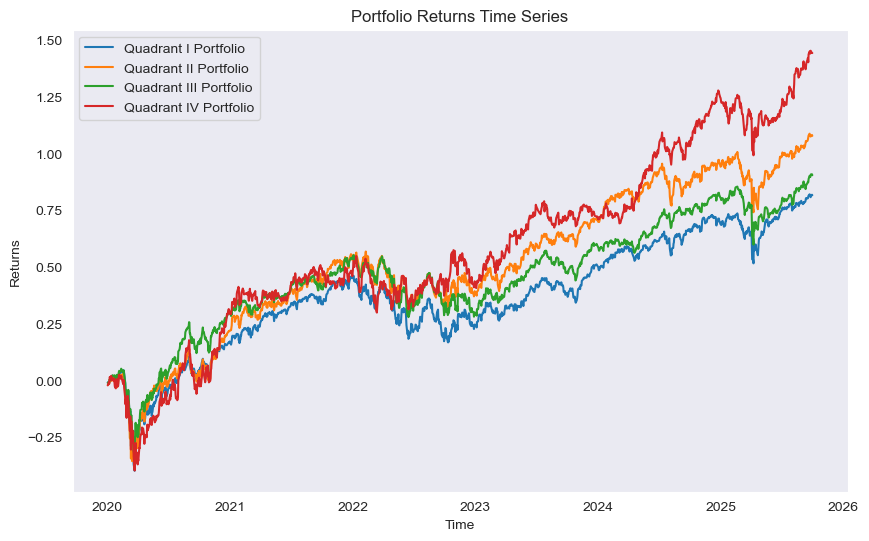

In [40]:
# Create Plot
plt.figure(figsize=(10, 6))
plt.plot(pure_pasive_portfolio.cumsum(), label='Quadrant I Portfolio', alpha=1)
plt.plot(aaps_portfolio.cumsum(), label='Quadrant II Portfolio', alpha=1)
plt.plot(paas_portfolio.cumsum(), label='Quadrant III Portfolio', alpha=1)
plt.plot(pure_active_portfolio.cumsum(), label='Quadrant IV Portfolio', alpha=1)

# Config
plt.title('Portfolio Returns Time Series')
plt.xlabel('Time')
plt.ylabel('Returns')
plt.legend()
plt.grid()

# Show
plt.show() 

In [41]:
# Now calculate the cumulative returns
quadrant_1_return = pure_pasive_portfolio.cumsum().iloc[-1]
quadrant_2_return = aaps_portfolio.cumsum().iloc[-1]
quadrant_3_return = paas_portfolio.cumsum().iloc[-1]
quadrant_4_return = pure_active_portfolio.cumsum().iloc[-1]

print(f'Quadrant 1 Return: {quadrant_1_return}')
print(f'Quadrant 2 Return: {quadrant_2_return}')
print(f'Quadrant 3 Return: {quadrant_3_return}')
print(f'Quadrant 4 Return: {quadrant_4_return}')

Quadrant 1 Return: 0.8164260725275332
Quadrant 2 Return: 1.0781800267646926
Quadrant 3 Return: 0.9046867667612055
Quadrant 4 Return: 1.4430000000000003


In [42]:
# The Excess Returns (we calculated it previously)
excess_returns

0.6265739274724671

In [43]:
# Market Timing Effect:
market_timing_effect = quadrant_2_return - quadrant_1_return

print(f'Market Timing Effect: {market_timing_effect}')

Market Timing Effect: 0.2617539542371594


In [44]:
# Security Selection Effect:
security_selection_effect = quadrant_3_return - quadrant_1_return

print(f'Security Selection Effect: {security_selection_effect}')

Security Selection Effect: 0.08826069423367233


In [45]:
# Other Effects:
other_effects = quadrant_4_return + quadrant_1_return - quadrant_2_return - quadrant_3_return

print(f'Other Effects: {other_effects}')

Other Effects: 0.27655927900163557


In [46]:
# Total Effect (must be equal to the excess returns)
total_effect = market_timing_effect + security_selection_effect + other_effects

print(f'Total Effect: {total_effect}')

Total Effect: 0.6265739274724673


In [47]:
# Check that both models provide the same results
brinson_fachler_df.sum()

allocation     0.261754
selection      0.088261
interaction    0.276559
total          0.626574
dtype: float64